<a href="https://colab.research.google.com/github/FebriansyahMonanda83/Data_Science_1606/blob/main/STUDI_KASUS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =================================================================
# STUDI KASUS ANALISIS DPT 142.XLSX: INKLUSIVITAS & PREDIKSI TPS
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. MOUNT DRIVE & LOAD DATA
drive.mount('/content/drive')
path = '/content/drive/My Drive/DPT_1606/142.xlsx'

try:
    df = pd.read_excel(path)
    # Standardisasi Nama Kolom
    df.columns = [c.strip().replace(' ', '_').upper() for c in df.columns]
    print("✅ Data berhasil dimuat dan kolom telah distandarisasi.")
except Exception as e:
    print(f"❌ Error: {e}")

Mounted at /content/drive
✅ Data berhasil dimuat dan kolom telah distandarisasi.


In [2]:
# =================================================================
# 2. FEATURE ENGINEERING (Rekayasa Fitur)
# =================================================================

# A. Menghitung Usia & Generasi (Tahun Analisis 2026)
if 'TANGGAL_LAHIR' in df.columns:
    df['TANGGAL_LAHIR'] = pd.to_datetime(df['TANGGAL_LAHIR'], errors='coerce')
    df['USIA'] = 2026 - df['TANGGAL_LAHIR'].dt.year

    def kategori_gen(u):
        if u <= 27: return 'Gen Z'
        elif u <= 43: return 'Milenial'
        elif u <= 59: return 'Gen X'
        else: return 'Baby Boomer/Silent'
    df['GENERASI'] = df['USIA'].apply(kategori_gen)

# B. Mengolah Data Disabilitas
# Mapping: 0:Non, 1:Fisik, 2:Intelektual, 3:Mental, 4:Wicara, 5:Rungu, 6:Netra
map_dis = {'0': 'Non', '1': 'Fisik', '2': 'Intelektual', '3': 'Mental',
           '4': 'Wicara', '5': 'Rungu', '6': 'Netra'}
df['LABEL_DISABILITAS'] = df['DISABILITAS'].fillna('0').astype(str).map(map_dis)
df['IS_DISABILITAS'] = df['DISABILITAS'].fillna('0').apply(lambda x: 1 if x != '0' else 0)

/tmp/ipykernel_20647/3089206316.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='GENERASI', palette='viridis', ax=ax[0])
/tmp/ipykernel_20647/3089206316.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_dis, y='LABEL_DISABILITAS', palette='magma', ax=ax[1])


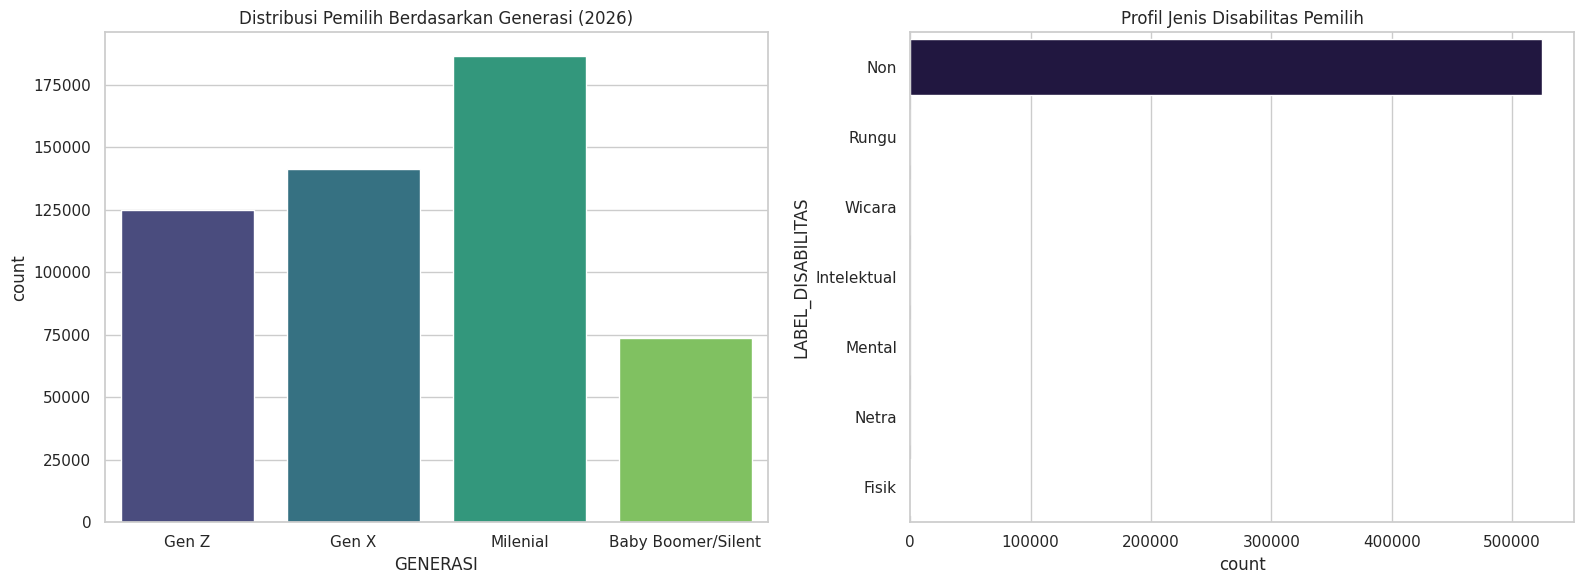

In [3]:
# =================================================================
# 3. VISUALISASI (Exploratory Data Analysis)
# =================================================================

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Sebaran Generasi
sns.countplot(data=df, x='GENERASI', palette='viridis', ax=ax[0])
ax[0].set_title('Distribusi Pemilih Berdasarkan Generasi (2026)')

# Plot 2: Distribusi Disabilitas (Hanya yang memiliki disabilitas)
df_dis = df[df['IS_DISABILITAS'] == 1]
if not df_dis.empty:
    sns.countplot(data=df_dis, y='LABEL_DISABILITAS', palette='magma', ax=ax[1])
    ax[1].set_title('Profil Jenis Disabilitas Pemilih')
else:
    ax[1].text(0.5, 0.5, 'Tidak ada data disabilitas', ha='center')

plt.tight_layout()
plt.show()

In [4]:
# =================================================================
# 4. REGRESI (Prediksi Waktu Pelayanan TPS)
# =================================================================

# Agregasi per TPS
tps_stats = df.groupby('TPS').agg({
    'IS_DISABILITAS': 'sum',
    'USIA': 'mean',
    'NIK': 'count'
}).rename(columns={'NIK': 'TOTAL_PEMILIH', 'USIA': 'RATA_USIA_TPS'})

# Skenario: Menghitung "Beban Waktu" (Menit)
# Asumsi: Dasar 2 mnt/orang, tambahan 5 mnt jika disabilitas, 0.2 mnt per kenaikan usia
tps_stats['ESTIMASI_DURASI'] = (tps_stats['TOTAL_PEMILIH'] * 2) + \
                               (tps_stats['IS_DISABILITAS'] * 5) + \
                               (tps_stats['RATA_USIA_TPS'] * 0.2) + \
                               np.random.normal(0, 5, len(tps_stats))

# Pemodelan Regresi
X = tps_stats[['TOTAL_PEMILIH', 'IS_DISABILITAS']]
y = tps_stats['ESTIMASI_DURASI']
model = LinearRegression().fit(X, y)

print("\n--- ANALISIS REGRESI ---")
print(f"Koefisien Disabilitas: {model.coef_[1]:.2f}")
print(f"Artinya: Setiap 1 pemilih disabilitas menambah waktu pelayanan TPS sebesar {model.coef_[1]:.2f} menit.")


--- ANALISIS REGRESI ---
Koefisien Disabilitas: 3.50
Artinya: Setiap 1 pemilih disabilitas menambah waktu pelayanan TPS sebesar 3.50 menit.


In [5]:
# =================================================================
# 5. SIMULASI PARTISIPASI (Monte Carlo)
# =================================================================

# Probabilitas kehadiran berdasarkan Generasi (Asumsi)
turnout_prob = {'Gen Z': 0.70, 'Milenial': 0.75, 'Gen X': 0.85, 'Baby Boomer/Silent': 0.90}

def hitung_kehadiran(gen):
    return 1 if np.random.random() < turnout_prob.get(gen, 0.5) else 0

# Simulasi 500 kali skenario pemungutan suara
simulasi_total = []
for _ in range(500):
    jumlah_hadir = df['GENERASI'].apply(hitung_kehadiran).sum()
    simulasi_total.append(jumlah_hadir)

print("\n--- KESIMPULAN STRATEGIS ---")
print(f"1. Total Pemilih Terdaftar: {len(df)}")
print(f"2. Prediksi Rata-rata Pemilih Datang: {int(np.mean(simulasi_total))} orang")
print(f"3. Rekomendasi: TPS dengan banyak disabilitas {df_dis['LABEL_DISABILITAS'].unique()} memerlukan asistensi ekstra.")


--- KESIMPULAN STRATEGIS ---
1. Total Pemilih Terdaftar: 526372
2. Prediksi Rata-rata Pemilih Datang: 413722 orang
3. Rekomendasi: TPS dengan banyak disabilitas ['Non' 'Rungu' 'Wicara' 'Intelektual' 'Mental' 'Netra' 'Fisik'] memerlukan asistensi ekstra.
